In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


In [2]:
celltype_colors <- c(
  NK = "#6A0DAD",          
  T = "#9B59B6",           
  Endothelial = "#CF1B14", 
  Myeloid = "#E8773B",     
  B = "#E995E7",           
  Cholangiocyte = "#E1AD01",
  HSC = "#4682B4",         
  Mast = "#FD7BB8",        
  Schwann = "#81CDC6",     
  Hepatocytes = "#4DAF4A"  
)

In [3]:
summary.df.ac <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/H3K27acQTL.summary.tsv', header=T)
summary.df.ac$modality <- 'H3K27ac'
summary.df.ac

cell,features,features.sig,tests,tests.sig,modality
<chr>,<int>,<int>,<int>,<int>,<chr>
Endothelial,105649,33,411121303,1653,H3K27ac
Hepatocytes,262182,370,1018657805,19948,H3K27ac
T,16377,1,61851248,29,H3K27ac
HSC,45585,0,176151028,0,H3K27ac
Cholangiocyte,63689,0,249920083,0,H3K27ac
Myeloid,112699,14,437918020,697,H3K27ac
NK,9380,0,35207383,0,H3K27ac
B,13278,0,49740291,0,H3K27ac
Bulk,379410,442,1493678770,23448,H3K27ac


In [4]:
summary.df.ATAC <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/caQTL.summary.tsv', header=T)
summary.df.ATAC$modality <- 'ATAC'
summary.df.ATAC

cell,features,features.sig,tests,tests.sig,modality
<chr>,<int>,<int>,<dbl>,<int>,<chr>
Endothelial,144545,1855,563384880,118509,ATAC
Hepatocytes,538131,6106,2122940846,431981,ATAC
T,25183,54,94648391,3024,ATAC
HSC,113189,443,443283389,28138,ATAC
Cholangiocyte,44523,64,171935060,3050,ATAC
Myeloid,167122,2047,649658272,138250,ATAC
NK,21178,16,79327065,1357,ATAC
B,20339,6,76205498,637,ATAC
Bulk,592835,7299,2351559812,520153,ATAC


In [5]:
summary.df.RNA <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/eQTL.summary.tsv', header=T)
summary.df.RNA$modality <- 'RNA'
summary.df.RNA

cell,features,features.sig,tests,tests.sig,modality
<chr>,<int>,<int>,<int>,<int>,<chr>
Endothelial,15439,293,58978117,23747,RNA
Hepatocytes,20180,871,77083441,75380,RNA
T,7024,21,26833839,3904,RNA
HSC,13639,94,52290358,8952,RNA
Cholangiocyte,11115,51,42591782,8140,RNA
Myeloid,13709,284,52174011,27044,RNA
NK,6230,23,23778685,3710,RNA
B,6928,7,26698524,653,RNA
Bulk,23309,961,89455348,88536,RNA


In [6]:
summary.df.me3 <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/H3K27me3QTL.summary.tsv', header=T)
summary.df.me3$modality <- 'H3K27me3'
summary.df.me3

cell,features,features.sig,tests,tests.sig,modality
<chr>,<int>,<int>,<int>,<int>,<chr>
Endothelial,115961,0,473405994,0,H3K27me3
Hepatocytes,425751,388,1780298783,31798,H3K27me3
T,14066,0,54571947,0,H3K27me3
HSC,21015,0,82813105,0,H3K27me3
Cholangiocyte,87146,1,357665323,54,H3K27me3
Myeloid,268394,2,1099830089,101,H3K27me3
NK,2632,0,9940030,0,H3K27me3
B,1240,0,4652675,0,H3K27me3
Bulk,455078,356,1897044825,36142,H3K27me3


In [7]:
summary.df <- rbind(summary.df.ATAC, summary.df.RNA) %>%
    rbind(summary.df.ac) %>%
    rbind(summary.df.me3)

summary.df

cell,features,features.sig,tests,tests.sig,modality
<chr>,<int>,<int>,<dbl>,<int>,<chr>
Endothelial,144545,1855,563384880,118509,ATAC
Hepatocytes,538131,6106,2122940846,431981,ATAC
T,25183,54,94648391,3024,ATAC
HSC,113189,443,443283389,28138,ATAC
Cholangiocyte,44523,64,171935060,3050,ATAC
Myeloid,167122,2047,649658272,138250,ATAC
NK,21178,16,79327065,1357,ATAC
B,20339,6,76205498,637,ATAC
Bulk,592835,7299,2351559812,520153,ATAC


In [8]:
arrange(summary.df.ATAC, -features.sig)$cell

[1] "Bulk"          "Hepatocytes"   "Myeloid"       "Endothelial"  
[5] "HSC"           "Cholangiocyte" "T"             "NK"           
[9] "B"

In [9]:
summary.df

cell,features,features.sig,tests,tests.sig,modality
<chr>,<int>,<int>,<dbl>,<int>,<chr>
Endothelial,144545,1855,563384880,118509,ATAC
Hepatocytes,538131,6106,2122940846,431981,ATAC
T,25183,54,94648391,3024,ATAC
HSC,113189,443,443283389,28138,ATAC
Cholangiocyte,44523,64,171935060,3050,ATAC
Myeloid,167122,2047,649658272,138250,ATAC
NK,21178,16,79327065,1357,ATAC
B,20339,6,76205498,637,ATAC
Bulk,592835,7299,2351559812,520153,ATAC


png 
  2

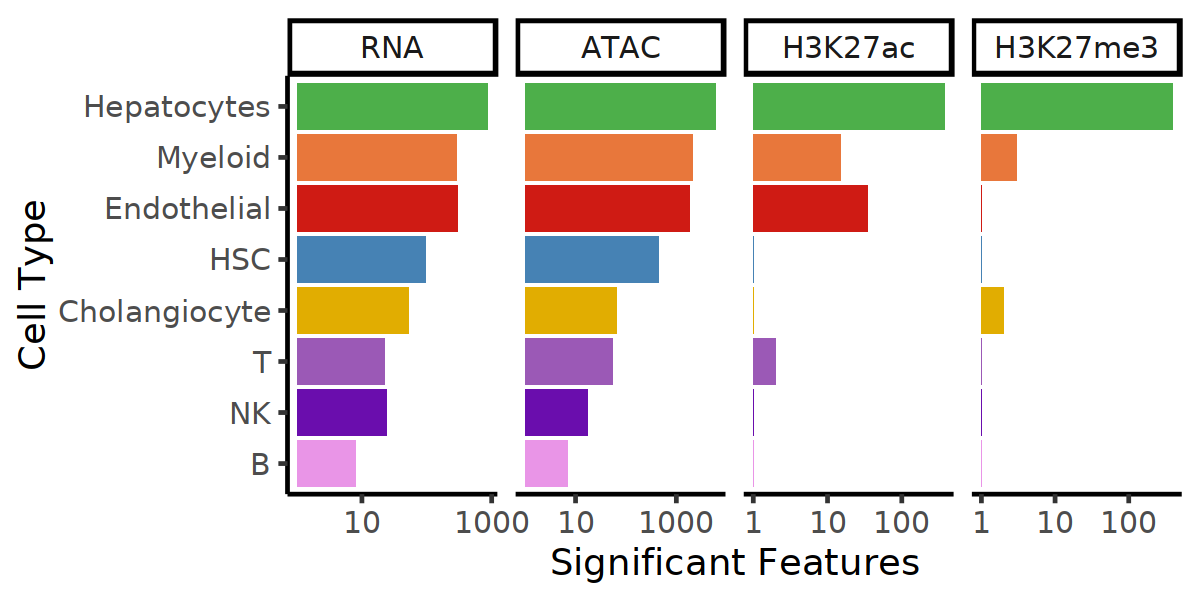

In [21]:
options(repr.plot.width=10, repr.plot.height=5)

summary.df$modality <- factor(summary.df$modality, levels=c('RNA','ATAC','H3K27ac','H3K27me3'))
summary.df$cell <- factor(summary.df$cell, levels=rev(arrange(summary.df.ATAC, -features.sig)$cell))
#summary.df

p1 <- ggplot(mutate(filter(summary.df, cell != 'Bulk'), features.sig=features.sig + 1), aes(x=cell, y=features.sig, fill=cell)) +
    geom_col(position='dodge') + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=22) +
    facet_grid(~modality, scales = 'free_x') + coord_flip() +#, scales = 'free', nrow = 4) + coord_flip() +
    labs(y="Significant Features", x='Cell Type') + theme(legend.position='none') + scale_y_log10(n.breaks = 4)

p1

pdf('/nfs/lab/welison/Liver/Plots/241212_WE_QTL_Summary_log_scale.pdf', height=5, width=10)
p1
dev.off()

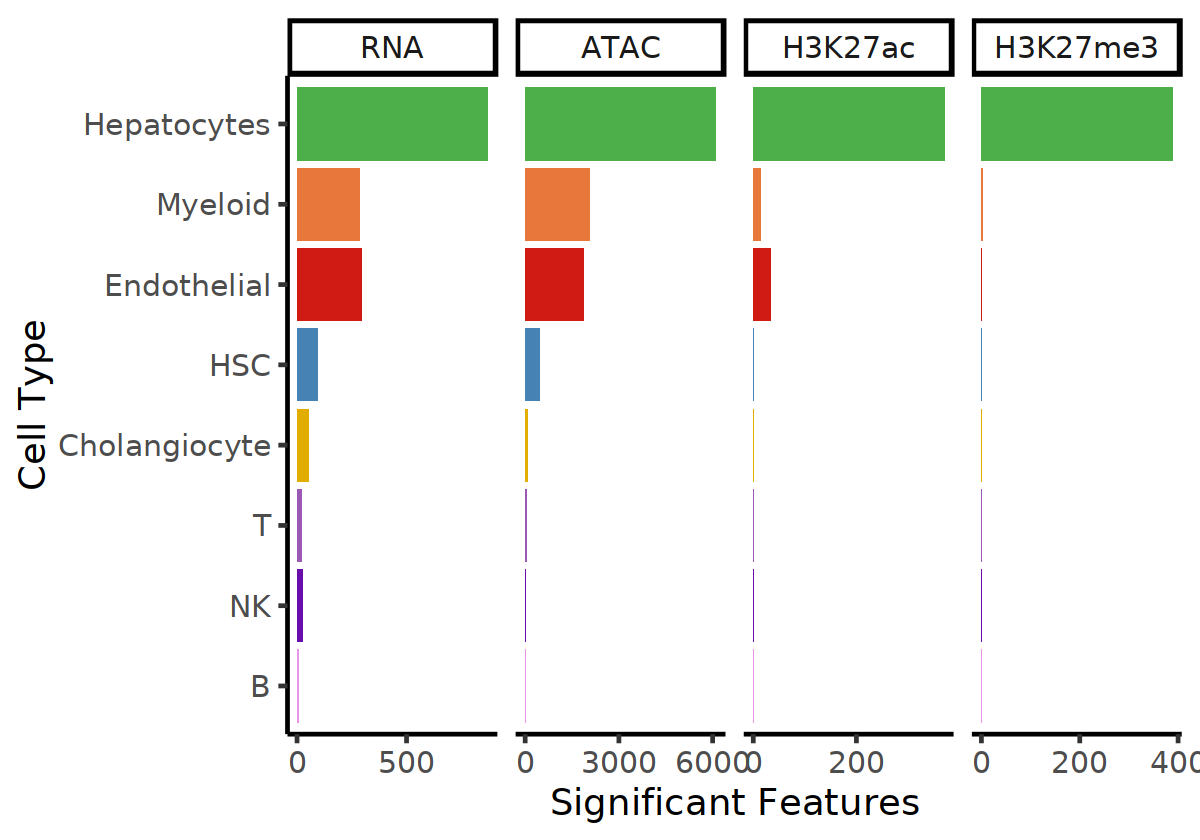

In [12]:
options(repr.plot.width=10, repr.plot.height=7)

summary.df$modality <- factor(summary.df$modality, levels=c('RNA','ATAC','H3K27ac','H3K27me3'))
summary.df$cell <- factor(summary.df$cell, levels=rev(arrange(summary.df.ATAC, -features.sig)$cell))
#summary.df

ggplot(filter(summary.df, cell != 'Bulk'), aes(x=cell, y=features.sig, fill=cell)) +
    geom_col(position='dodge') + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=22) +
    facet_grid(~modality, scales = 'free_x') + coord_flip() +#, scales = 'free', nrow = 4) + coord_flip() +
    labs(y="Significant Features", x='Cell Type') + theme(legend.position='none') + scale_y_continuous(n.breaks = 3)

In [13]:
pdf('/nfs/lab/welison/Liver/Plots/241212_WE_QTL_Summary.pdf', height=7, width=10)
ggplot(filter(summary.df, cell != 'Bulk'), aes(x=cell, y=features.sig, fill=cell)) +
    geom_col(position='dodge') + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=22) +
    facet_grid(~modality, scales = 'free_x') + coord_flip() +#, scales = 'free', nrow = 4) + coord_flip() +
    labs(y="Significant Features", x='Cell Type') + theme(legend.position='none') + scale_y_continuous(n.breaks = 3)
dev.off()

png 
  2

In [33]:
p1 <- ggplot(filter(summary.df, cell != 'Bulk'), aes(x=cell, y=features.sig, fill=cell)) +
    geom_col(position='dodge') + 
    scale_fill_manual(values=celltype_colors) + theme_classic(base_size=22) +
    facet_grid(~modality, scales = 'free_x') + coord_flip() +#, scales = 'free', nrow = 4) + coord_flip() +
    labs(y="Significant Features", x='Cell Type') + theme(legend.position='none') + scale_y_continuous(n.breaks = 3)


ggsave(filename = '/nfs/lab/welison/Liver/Plots/241212_WE_QTL_Summary_ggsave.pdf', p1, width = 10, height=7)

# Susie

In [14]:
susie.ac <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/06_H3K27acQTLs/outs/SuSiE.plot.data.tsv', header=T)
susie.ac$modality <- 'H3K27ac'
dim(susie.ac)
head(susie.ac)

[1] 419   7

,phenotype_id,cs_id,celltype,n,group,value,modality
,<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>
1,chr10:11736837-11737836,1,Hepatocytes,1,1,1,H3K27ac
2,chr10:35457994-35458993,1,Hepatocytes,1,1,1,H3K27ac
3,chr10:71302879-71303878,1,Hepatocytes,1,1,1,H3K27ac
4,chr11:107157575-107158574,1,Hepatocytes,1,1,1,H3K27ac
5,chr11:126365359-126366358,1,Hepatocytes,1,1,1,H3K27ac
6,chr12:131850905-131851904,1,Hepatocytes,1,1,1,H3K27ac


In [15]:
susie.me3 <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/07_H3K27me3QTLs/outs/SuSiE.plot.data.tsv', header=T)
susie.me3$modality <- 'H3K27me3'
dim(susie.me3)
head(susie.me3)

[1] 392   7

,phenotype_id,cs_id,celltype,n,group,value,modality
,<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>
1,chr12:131663289-131664788,1,Hepatocytes,1,1,1,H3K27me3
2,chr12:54139502-54141001,1,Hepatocytes,1,1,1,H3K27me3
3,chr12:54145492-54146991,1,Hepatocytes,1,1,1,H3K27me3
4,chr12:54161475-54162974,1,Hepatocytes,1,1,1,H3K27me3
5,chr14:105161822-105163321,1,Hepatocytes,1,1,1,H3K27me3
6,chr14:23683999-23685498,1,Hepatocytes,1,1,1,H3K27me3


In [16]:
susie.atac <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/05_caQTLs/outs/SuSiE.plot.data.tsv', header=T)
susie.atac$modality <- 'ATAC'
dim(susie.atac)
head(susie.atac)

[1] 10712     7

,phenotype_id,cs_id,celltype,n,group,value,modality
,<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>
1,chr1-109306093-109306393,2,Hepatocytes,1,1,1,ATAC
2,chr1-110433840-110434140,1,Myeloid,1,1,1,ATAC
3,chr1-111193073-111193373,1,Endothelial,1,1,1,ATAC
4,chr1-113947068-113947309,1,Hepatocytes,1,1,1,ATAC
5,chr1-11749184-11749484,1,Hepatocytes,1,1,1,ATAC
6,chr1-1420065-1420365,1,Hepatocytes,1,1,1,ATAC


In [17]:
susie.rna <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/tensorQTL/04_eQTLs/outs/SuSiE.plot.data.tsv', header=T)
susie.rna$modality <- 'RNA'
dim(susie.rna)
head(susie.rna)

[1] 1669    7

,phenotype_id,cs_id,celltype,n,group,value,modality
,<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>
1,AC002074.1,1,Endothelial,1,1,1,RNA
2,AC002074.1,1,HSC,1,1,1,RNA
3,AC004540.1,1,Myeloid,1,1,1,RNA
4,AC005532.1,1,Hepatocytes,1,1,1,RNA
5,AC007216.2,1,Hepatocytes,1,1,1,RNA
6,AC007535.1,1,Hepatocytes,1,1,1,RNA


In [24]:
susie <- rbind(susie.atac, susie.rna) %>%
    rbind(susie.ac) %>%
    rbind(susie.me3)

susie

phenotype_id,cs_id,celltype,n,group,value,modality
<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>
chr1-109306093-109306393,2,Hepatocytes,1,1,1,ATAC
chr1-110433840-110434140,1,Myeloid,1,1,1,ATAC
chr1-111193073-111193373,1,Endothelial,1,1,1,ATAC
chr1-113947068-113947309,1,Hepatocytes,1,1,1,ATAC
chr1-11749184-11749484,1,Hepatocytes,1,1,1,ATAC
chr1-1420065-1420365,1,Hepatocytes,1,1,1,ATAC
chr1-148139194-148139494,1,Hepatocytes,1,1,1,ATAC
chr1-151809689-151809989,1,Hepatocytes,1,1,1,ATAC
chr1-15282060-15282360,1,Hepatocytes,1,1,1,ATAC


In [4]:
colorRampPalette(park_palette("Acadia")[c(5,4,2)])(5)

[1] "#A4BED5" "#7596AC" "#476F84" "#245363" "#023743"

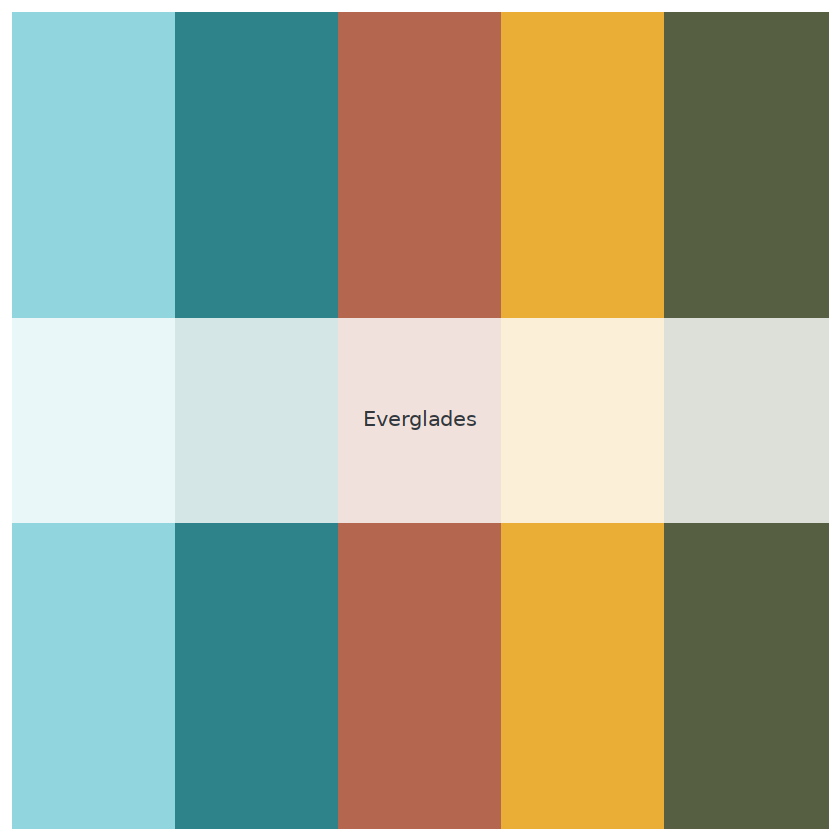

In [11]:
park_palette("Everglades")

In [1]:
library(nationalparkcolors)

In [25]:
susie

phenotype_id,cs_id,celltype,n,group,value,modality
<chr>,<int>,<chr>,<int>,<chr>,<int>,<chr>
chr1-109306093-109306393,2,Hepatocytes,1,1,1,ATAC
chr1-110433840-110434140,1,Myeloid,1,1,1,ATAC
chr1-111193073-111193373,1,Endothelial,1,1,1,ATAC
chr1-113947068-113947309,1,Hepatocytes,1,1,1,ATAC
chr1-11749184-11749484,1,Hepatocytes,1,1,1,ATAC
chr1-1420065-1420365,1,Hepatocytes,1,1,1,ATAC
chr1-148139194-148139494,1,Hepatocytes,1,1,1,ATAC
chr1-151809689-151809989,1,Hepatocytes,1,1,1,ATAC
chr1-15282060-15282360,1,Hepatocytes,1,1,1,ATAC


In [26]:
sorted.sum <- filter(susie, modality=='ATAC') %>%
    group_by(celltype) %>% 
    summarise(count=n()) %>%
    arrange(count)
sorted.sum


celltype,count
<chr>,<int>
B,6
NK,16
T,54
Cholangiocyte,64
HSC,454
Endothelial,1878
Myeloid,2072
Hepatocytes,6168


In [29]:
unique(susie$group)

[1] "1"   "2-3" "4-5" "6-7" "8-9" "10+"

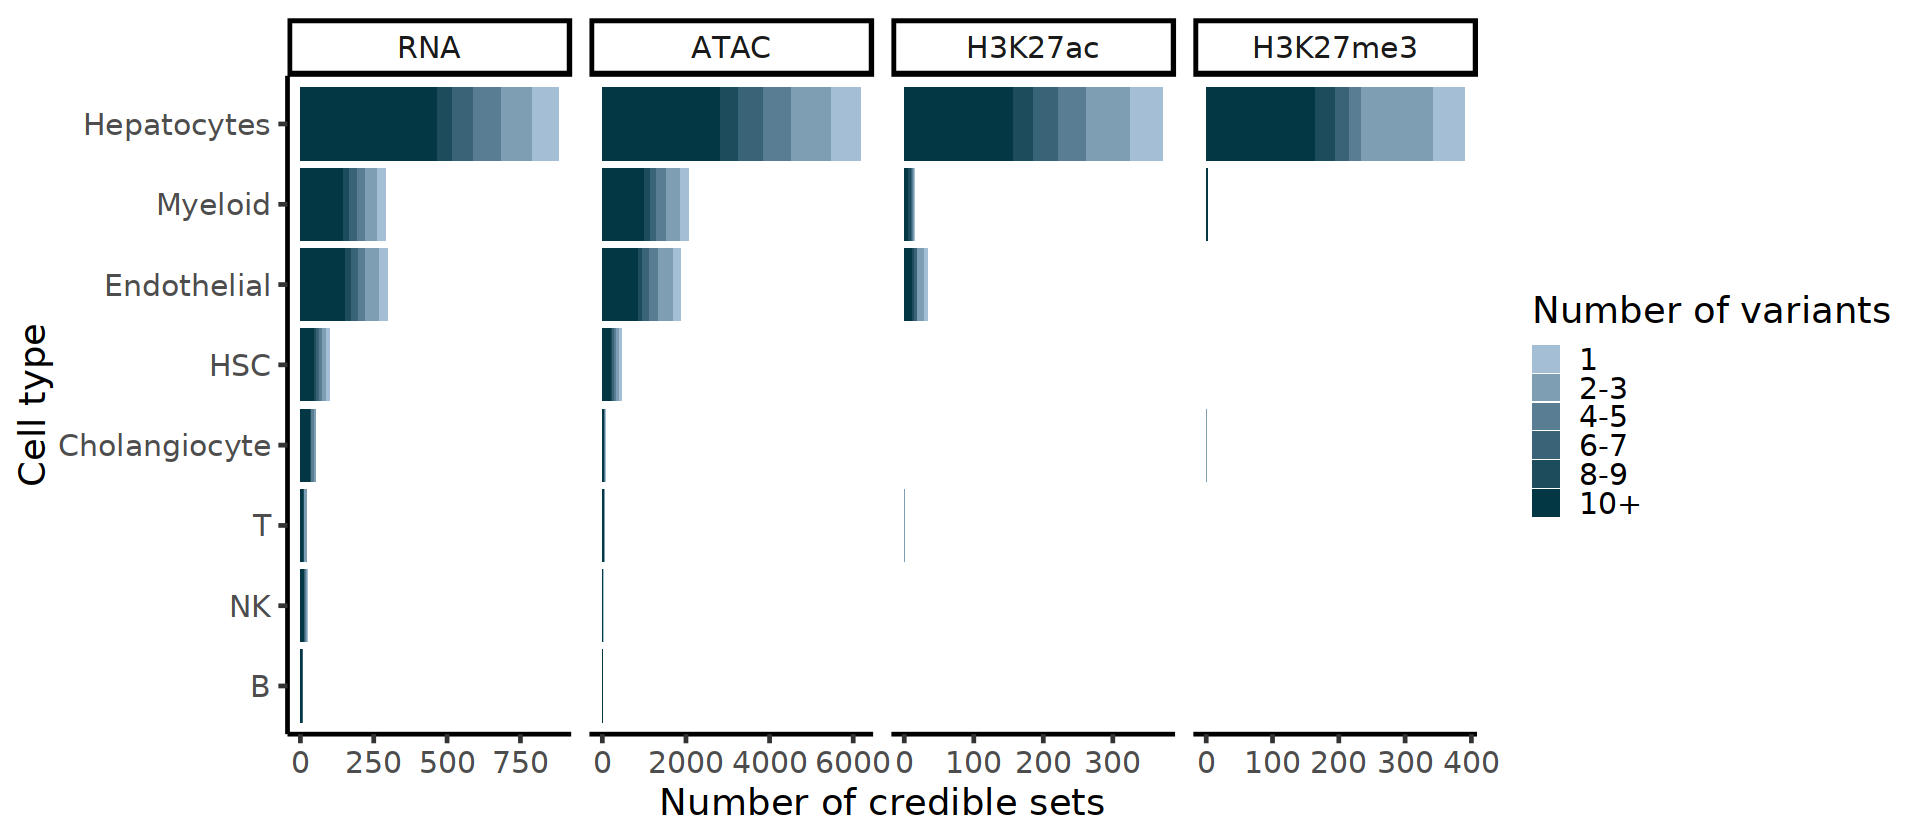

In [30]:
options(repr.plot.width=16)
susie$value <- 1
susie$group <- factor(susie$group, levels=c('1','2-3','4-5','6-7','8-9','10+'))
susie$celltype <- factor(susie$celltype, levels=sorted.sum$celltype)
susie$modality <- factor(susie$modality, levels=c('RNA','ATAC','H3K27ac','H3K27me3'))

ggplot(susie, aes(x=celltype, y=value, fill=group)) + geom_col() +
    scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(susie$group)))) +
    theme_classic(base_size=22) + coord_flip() + ylab("Number of credible sets") + 
    xlab('Cell type') + labs(fill='Number of variants') +    
    facet_grid(~modality, scales = 'free_x') 

In [32]:
pdf('/nfs/lab/welison/Liver/Plots/241212_WE_QTL_SuSiE.pdf', height=8, width=14)
ggplot(susie, aes(x=celltype, y=value, fill=group)) + geom_col() +
    scale_fill_manual(values=colorRampPalette(park_palette("Acadia")[c(5,4,2)])(length(levels(susie$group)))) +
    theme_classic(base_size=22) + coord_flip() + ylab("Number of credible sets") + 
    xlab('Cell type') + labs(fill='Number of variants') +    
    facet_grid(~modality, scales = 'free_x') 
dev.off()

png 
  2